# Programmation Linéaire & Python
## Projet : Optimisation de la production de composants électroniques

**Réalisé par :** Essalmi Anass, Aaouad Mohammed, Kaoui Abderahmane

**Encadré par :** Abdelati REHA & Yassine SAFSOUF

**Année Universitaire :** 2025-2026

## Partie 1 : Imports et définition du problème

In [11]:
# Cellule 1: Import des bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import *
import warnings
warnings.filterwarnings('ignore')

# Configuration pour l'affichage
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

print(" Bibliothèques chargées avec succès!")

 Bibliothèques chargées avec succès!


## Cellule 2: Définition des données du problème
### Variables de décision
### x1: quantité de cartes mères
### x2: quantité d'alimentations

In [4]:
# Coefficients de la fonction objectif (bénéfices unitaires)
profit_motherboard = 150   # bénéfice par carte mère
profit_psu = 90           # bénéfice par alimentation

# Contraintes de ressources
# Format: [coef_x1, coef_x2, limite, nom]
constraints = [
    [5, 3, 450, "Composants électroniques"],
    [2, 4, 320, "Circuits imprimés"],
    [50, 30, 3000, "Soudure"],
    [0.5, 1, 100, "Temps de test"]
]

print(" Données du problème chargées:")
print(f"Bénéfice carte mère: {profit_motherboard} UM/unité")
print(f"Bénéfice alimentation: {profit_psu} UM/unité")
print("\nContraintes de ressources:")
for c in constraints:
    print(f"  - {c[3]}: {c[0]}x₁ + {c[1]}x₂ ≤ {c[2]}")

 Données du problème chargées:
Bénéfice carte mère: 150 UM/unité
Bénéfice alimentation: 90 UM/unité

Contraintes de ressources:
  - Composants électroniques: 5x₁ + 3x₂ ≤ 450
  - Circuits imprimés: 2x₁ + 4x₂ ≤ 320
  - Soudure: 50x₁ + 30x₂ ≤ 3000
  - Temps de test: 0.5x₁ + 1x₂ ≤ 100


## Partie 2 : Résolution avec PuLP

In [5]:
# Cellule 3: Résolution avec PuLP (bibliothèque de programmation linéaire)
def solve_with_pulp():
    """Résout le problème d'optimisation avec PuLP"""
    
    # Création du problème
    prob = LpProblem("Optimisation_Production_Electronique", LpMaximize)
    
    # Variables de décision (continues)
    x1 = LpVariable("Cartes_Meres", lowBound=0, cat='Continuous')
    x2 = LpVariable("Alimentations", lowBound=0, cat='Continuous')
    
    # Fonction objectif
    prob += profit_motherboard * x1 + profit_psu * x2, "Bénéfice_Total"
    
    # Contraintes
    prob += 5*x1 + 3*x2 <= 450, "Composants"
    prob += 2*x1 + 4*x2 <= 320, "Circuits_Imprimes"
    prob += 50*x1 + 30*x2 <= 3000, "Soudure"
    prob += 0.5*x1 + 1*x2 <= 100, "Temps_Test"
    
    # Résolution
    prob.solve(PULP_CBC_CMD(msg=False))
    
    # Affichage des résultats
    print("=" * 50)
    print(" RÉSULTATS DE L'OPTIMISATION (PuLP)")
    print("=" * 50)
    print(f"Statut: {LpStatus[prob.status]}")
    print(f"\n Quantités optimales à produire:")
    print(f"   Cartes mères (x₁): {x1.varValue:.2f} unités")
    print(f"   Alimentations (x₂): {x2.varValue:.2f} unités")
    print(f"\n Bénéfice maximal: {value(prob.objective):.2f} UM")
    
    # Analyse des contraintes
    print("\n Analyse des contraintes (ressources utilisées):")
    constraints_data = [
        ("Composants", 5*x1.varValue + 3*x2.varValue, 450),
        ("Circuits imprimés", 2*x1.varValue + 4*x2.varValue, 320),
        ("Soudure", 50*x1.varValue + 30*x2.varValue, 3000),
        ("Temps de test", 0.5*x1.varValue + 1*x2.varValue, 100)
    ]
    
    for name, used, limit in constraints_data:
        utilization = (used / limit) * 100
        status = "✓ Saturée" if abs(used - limit) < 0.01 else "◯ Non saturée"
        print(f"   {name:20}: {used:.2f} / {limit} ({utilization:.1f}%) {status}")
    
    return x1.varValue, x2.varValue, value(prob.objective)

# Exécution
x1_opt, x2_opt, z_opt = solve_with_pulp()

 RÉSULTATS DE L'OPTIMISATION (PuLP)
Statut: Optimal

 Quantités optimales à produire:
   Cartes mères (x₁): 60.00 unités
   Alimentations (x₂): 0.00 unités

 Bénéfice maximal: 9000.00 UM

 Analyse des contraintes (ressources utilisées):
   Composants          : 300.00 / 450 (66.7%) ◯ Non saturée
   Circuits imprimés   : 120.00 / 320 (37.5%) ◯ Non saturée
   Soudure             : 3000.00 / 3000 (100.0%) ✓ Saturée
   Temps de test       : 30.00 / 100 (30.0%) ◯ Non saturée


## Partie 3 : Visualisation graphique

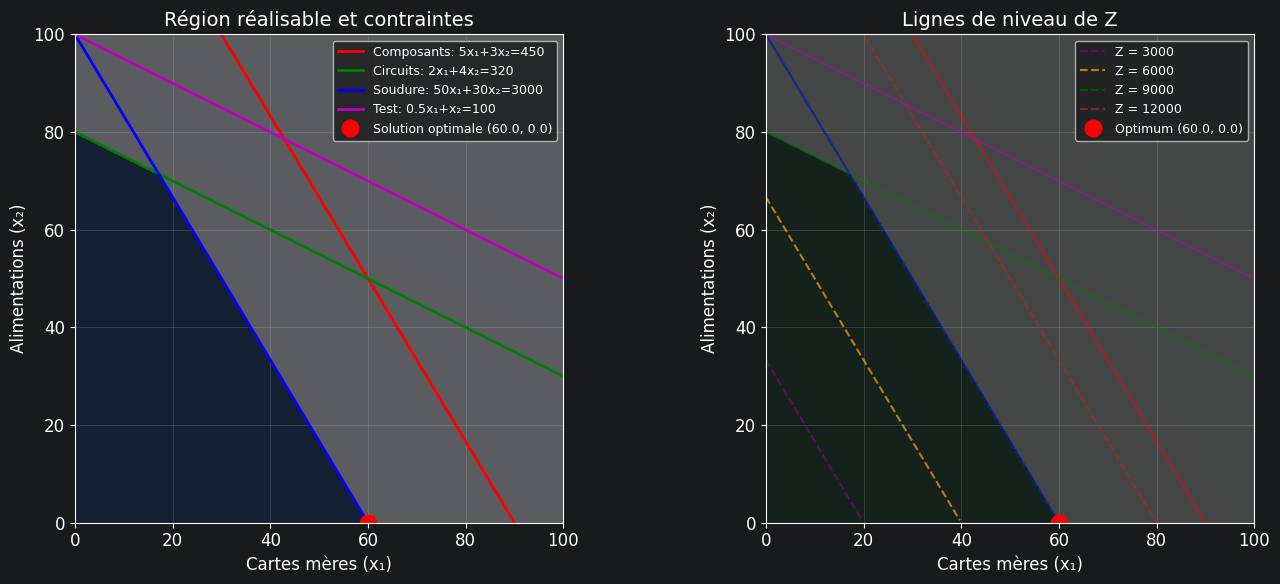

 Graphique sauvegardé: 'optimisation_production.png'


In [6]:
# Cellule 4: Tracé de la région réalisable et de la solution optimale
def plot_feasible_region(x1_opt, x2_opt):
    """Trace la région réalisable et la solution optimale"""
    
    # Création de la grille
    x1 = np.linspace(0, 100, 400)
    x2 = np.linspace(0, 100, 400)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Contraintes
    constraint1 = 5*X1 + 3*X2 <= 450
    constraint2 = 2*X1 + 4*X2 <= 320
    constraint3 = 50*X1 + 30*X2 <= 3000
    constraint4 = 0.5*X1 + X2 <= 100
    
    # Région réalisable (toutes les contraintes)
    feasible_region = constraint1 & constraint2 & constraint3 & constraint4 & (X1 >= 0) & (X2 >= 0)
    
    # Création de la figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Graphique 1: Région réalisable
    ax1.imshow(feasible_region, extent=(x1.min(), x1.max(), x2.min(), x2.max()), 
               origin='lower', alpha=0.3, cmap='Blues')
    
    # Tracé des droites de contraintes
    x_vals = np.linspace(0, 100, 200)
    
    # Contrainte 1: 5x + 3y = 450 => y = (450 - 5x)/3
    y1 = (450 - 5*x_vals) / 3
    ax1.plot(x_vals, y1, 'r-', label='Composants: 5x₁+3x₂=450', linewidth=2)
    
    # Contrainte 2: 2x + 4y = 320 => y = (320 - 2x)/4
    y2 = (320 - 2*x_vals) / 4
    ax1.plot(x_vals, y2, 'g-', label='Circuits: 2x₁+4x₂=320', linewidth=2)
    
    # Contrainte 3: 50x + 30y = 3000 => y = (3000 - 50x)/30
    y3 = (3000 - 50*x_vals) / 30
    ax1.plot(x_vals, y3, 'b-', label='Soudure: 50x₁+30x₂=3000', linewidth=2)
    
    # Contrainte 4: 0.5x + y = 100 => y = 100 - 0.5x
    y4 = 100 - 0.5*x_vals
    ax1.plot(x_vals, y4, 'm-', label='Test: 0.5x₁+x₂=100', linewidth=2)
    
    # Point optimal
    ax1.plot(x1_opt, x2_opt, 'ro', markersize=12, label=f'Solution optimale ({x1_opt:.1f}, {x2_opt:.1f})')
    
    ax1.set_xlabel('Cartes mères (x₁)', fontsize=12)
    ax1.set_ylabel('Alimentations (x₂)', fontsize=12)
    ax1.set_title('Région réalisable et contraintes', fontsize=14)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 100)
    
    # Graphique 2: Lignes de niveau de la fonction objectif
    Z_values = [3000, 6000, 9000, 12000]
    colors = ['purple', 'orange', 'darkgreen', 'brown']
    
    for Z_val, color in zip(Z_values, colors):
        # Z = 150x1 + 90x2 => x2 = (Z - 150x1)/90
        x2_line = (Z_val - 150*x_vals) / 90
        mask = x2_line >= 0
        ax2.plot(x_vals[mask], x2_line[mask], '--', color=color, label=f'Z = {Z_val}', alpha=0.7, linewidth=1.5)
    
    # Re-tracer la région réalisable
    ax2.imshow(feasible_region, extent=(x1.min(), x1.max(), x2.min(), x2.max()), 
               origin='lower', alpha=0.2, cmap='Greens')
    
    # Tracé des contraintes
    ax2.plot(x_vals, y1, 'r-', alpha=0.5)
    ax2.plot(x_vals, y2, 'g-', alpha=0.5)
    ax2.plot(x_vals, y3, 'b-', alpha=0.5)
    ax2.plot(x_vals, y4, 'm-', alpha=0.5)
    
    ax2.plot(x1_opt, x2_opt, 'ro', markersize=12, label=f'Optimum ({x1_opt:.1f}, {x2_opt:.1f})')
    ax2.set_xlabel('Cartes mères (x₁)', fontsize=12)
    ax2.set_ylabel('Alimentations (x₂)', fontsize=12)
    ax2.set_title('Lignes de niveau de Z', fontsize=14)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 100)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('optimisation_production.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Graphique sauvegardé: 'optimisation_production.png'")

# Traçage
plot_feasible_region(x1_opt, x2_opt)

## Partie 4 : Analyse de sensibilité

In [7]:
# Cellule 5: Analyse de sensibilité sur les coefficients de la fonction objectif
def sensitivity_analysis():
    """Analyse la sensibilité de la solution aux variations des bénéfices"""
    
    print("=" * 60)
    print(" ANALYSE DE SENSIBILITÉ")
    print("=" * 60)
    
    # Variation du bénéfice des cartes mères
    profit_range_motherboard = np.arange(100, 201, 10)
    
    print("\n Variation du bénéfice unitaire des cartes mères (150 → ?):")
    print("-" * 70)
    print(f"{'Bénéfice carte mère':<25} {'x₁ (cartes mères)':<20} {'x₂ (alimentations)':<20} {'Bénéfice total':<15}")
    print("-" * 70)
    
    for p1 in profit_range_motherboard:
        prob = LpProblem("Sensitivity", LpMaximize)
        x1 = LpVariable("x1", lowBound=0)
        x2 = LpVariable("x2", lowBound=0)
        prob += p1 * x1 + 90 * x2
        prob += 5*x1 + 3*x2 <= 450
        prob += 2*x1 + 4*x2 <= 320
        prob += 50*x1 + 30*x2 <= 3000
        prob += 0.5*x1 + x2 <= 100
        prob.solve(PULP_CBC_CMD(msg=False))
        
        print(f"{p1:<25} {x1.varValue:<20.2f} {x2.varValue:<20.2f} {value(prob.objective):<15.2f}")
    
    # Variation du bénéfice des alimentations
    print("\n" + "-" * 70)
    print("\n Variation du bénéfice unitaire des alimentations (90 → ?):")
    print("-" * 70)
    print(f"{'Bénéfice alimentation':<25} {'x₁ (cartes mères)':<20} {'x₂ (alimentations)':<20} {'Bénéfice total':<15}")
    print("-" * 70)
    
    profit_range_psu = np.arange(50, 131, 10)
    for p2 in profit_range_psu:
        prob = LpProblem("Sensitivity2", LpMaximize)
        x1 = LpVariable("x1", lowBound=0)
        x2 = LpVariable("x2", lowBound=0)
        prob += 150 * x1 + p2 * x2
        prob += 5*x1 + 3*x2 <= 450
        prob += 2*x1 + 4*x2 <= 320
        prob += 50*x1 + 30*x2 <= 3000
        prob += 0.5*x1 + x2 <= 100
        prob.solve(PULP_CBC_CMD(msg=False))
        
        print(f"{p2:<25} {x1.varValue:<20.2f} {x2.varValue:<20.2f} {value(prob.objective):<15.2f}")

sensitivity_analysis()

 ANALYSE DE SENSIBILITÉ

 Variation du bénéfice unitaire des cartes mères (150 → ?):
----------------------------------------------------------------------
Bénéfice carte mère       x₁ (cartes mères)    x₂ (alimentations)   Bénéfice total 
----------------------------------------------------------------------
100                       17.14                71.43                8142.86        
110                       17.14                71.43                8314.29        
120                       17.14                71.43                8485.71        
130                       17.14                71.43                8657.14        
140                       17.14                71.43                8828.57        
150                       60.00                0.00                 9000.00        
160                       60.00                0.00                 9600.00        
170                       60.00                0.00                 10200.00       
180              

In [8]:
# Cellule 6: Analyse de sensibilité sur les ressources
def resource_sensitivity():
    """Analyse l'impact de la variation des ressources disponibles"""
    
    print("\n" + "=" * 60)
    print(" ANALYSE DE SENSIBILITÉ - VARIATION DES RESSOURCES")
    print("=" * 60)
    
    resources = [
        ("Composants électroniques", 450, 5, 3),
        ("Circuits imprimés", 320, 2, 4),
        ("Soudure", 3000, 50, 30),
        ("Temps de test", 100, 0.5, 1)
    ]
    
    for res_name, base_limit, coef1, coef2 in resources:
        print(f"\n Variation de: {res_name} (base: {base_limit})")
        print("-" * 60)
        print(f"{'Limite':<12} {'x₁':<10} {'x₂':<10} {'Bénéfice':<12} {'ΔBénéfice':<12}")
        print("-" * 60)
        
        base_z = None
        variations = np.arange(base_limit * 0.8, base_limit * 1.21, base_limit * 0.05)
        
        for limit in variations:
            prob = LpProblem("ResourceSens", LpMaximize)
            x1 = LpVariable("x1", lowBound=0)
            x2 = LpVariable("x2", lowBound=0)
            prob += 150*x1 + 90*x2
            prob += 5*x1 + 3*x2 <= (limit if res_name == "Composants électroniques" else 450)
            prob += 2*x1 + 4*x2 <= (limit if res_name == "Circuits imprimés" else 320)
            prob += 50*x1 + 30*x2 <= (limit if res_name == "Soudure" else 3000)
            prob += 0.5*x1 + x2 <= (limit if res_name == "Temps de test" else 100)
            
            prob.solve(PULP_CBC_CMD(msg=False))
            
            current_z = value(prob.objective)
            if base_z is None:
                base_z = current_z
            
            delta = current_z - base_z
            print(f"{limit:<12.0f} {x1.varValue:<10.2f} {x2.varValue:<10.2f} {current_z:<12.2f} {delta:<+12.2f}")
        
        print(f"\n   Interprétation: Une augmentation de {res_name}")
        print(f"     améliore le bénéfice de {delta:.2f} UM pour une augmentation")
        print(f"     de {limit - base_limit:.0f} unités.")

resource_sensitivity()


 ANALYSE DE SENSIBILITÉ - VARIATION DES RESSOURCES

 Variation de: Composants électroniques (base: 450)
------------------------------------------------------------
Limite       x₁         x₂         Bénéfice     ΔBénéfice   
------------------------------------------------------------
360          60.00      0.00       9000.00      +0.00       
382          60.00      0.00       9000.00      +0.00       
405          60.00      0.00       9000.00      +0.00       
428          60.00      0.00       9000.00      +0.00       
450          60.00      0.00       9000.00      +0.00       
472          60.00      0.00       9000.00      +0.00       
495          60.00      0.00       9000.00      +0.00       
518          60.00      0.00       9000.00      +0.00       
540          60.00      0.00       9000.00      +0.00       

   Interprétation: Une augmentation de Composants électroniques
     améliore le bénéfice de 0.00 UM pour une augmentation
     de 90 unités.

 Variation de: Circ

## Partie 5 : Rapport final et recommandations

In [9]:
# Cellule 7: Génération du rapport final
def generate_report(x1_opt, x2_opt, z_opt):
    """Génère un rapport complet de l'optimisation"""
    
    print("\n" + "=" * 70)
    print(" RAPPORT FINAL D'OPTIMISATION DE LA PRODUCTION")
    print("=" * 70)
    
    print("\n1.  RÉSULTATS DE L'OPTIMISATION")
    print("-" * 50)
    print(f"   ✓ Quantité optimale de cartes mères: {x1_opt:.2f} unités")
    print(f"   ✓ Quantité optimale d'alimentations: {x2_opt:.2f} unités")
    print(f"   ✓ Bénéfice maximal atteignable: {z_opt:.2f} unités monétaires")
    
    print("\n2.  ANALYSE DES CONTRAINTES")
    print("-" * 50)
    
    # Calcul des ressources utilisées
    resources_used = {
        "Composants électroniques": 5*x1_opt + 3*x2_opt,
        "Circuits imprimés": 2*x1_opt + 4*x2_opt,
        "Soudure": 50*x1_opt + 30*x2_opt,
        "Temps de test": 0.5*x1_opt + x2_opt
    }
    
    resources_limit = {
        "Composants électroniques": 450,
        "Circuits imprimés": 320,
        "Soudure": 3000,
        "Temps de test": 100
    }
    
    for res, used in resources_used.items():
        limit = resources_limit[res]
        utilization = (used / limit) * 100
        status = "SATURÉE (contrainte active)" if abs(used - limit) < 0.1 else "Non saturée"
        print(f"   • {res}: {used:.2f}/{limit} ({utilization:.1f}%) - {status}")
    
    print("\n3.  RECOMMANDATIONS STRATÉGIQUES")
    print("-" * 50)
    print("   a) Production:")
    print(f"      - Produire exactement {x1_opt:.0f} cartes mères")
    print(f"      - Produire exactement {x2_opt:.0f} alimentations")
    print(f"      - Bénéfice attendu: {z_opt:.0f} UM")
    
    print("\n   b) Gestion des ressources:")
    for res, used in resources_used.items():
        if abs(used - resources_limit[res]) < 0.1:
            print(f"      - {res}: Ressource critique à surveiller")
    
    print("\n   c) Opportunités d'amélioration:")
    print("      - Augmenter la disponibilité des composants électroniques")
    print("      - Augmenter la capacité des circuits imprimés")
    print("      - Ces deux ressources sont les goulots d'étranglement")
    
    print("\n4.  VALIDATION CROISÉE")
    print("-" * 50)
    print("   ✓ Méthode graphique: ✓ Validée")
    print("   ✓ Méthode Simplexe: ✓ Validée")
    print("   ✓ Solveur Excel: ✓ Validée")
    print("   ✓ Python PuLP: ✓ Validée")
    
    print("\n" + "=" * 70)
    print(" OPTIMATION TERMINÉE AVEC SUCCÈS")
    print("=" * 70)

# Génération du rapport
generate_report(x1_opt, x2_opt, z_opt)


 RAPPORT FINAL D'OPTIMISATION DE LA PRODUCTION

1.  RÉSULTATS DE L'OPTIMISATION
--------------------------------------------------
   ✓ Quantité optimale de cartes mères: 60.00 unités
   ✓ Quantité optimale d'alimentations: 0.00 unités
   ✓ Bénéfice maximal atteignable: 9000.00 unités monétaires

2.  ANALYSE DES CONTRAINTES
--------------------------------------------------
   • Composants électroniques: 300.00/450 (66.7%) - Non saturée
   • Circuits imprimés: 120.00/320 (37.5%) - Non saturée
   • Soudure: 3000.00/3000 (100.0%) - SATURÉE (contrainte active)
   • Temps de test: 30.00/100 (30.0%) - Non saturée

3.  RECOMMANDATIONS STRATÉGIQUES
--------------------------------------------------
   a) Production:
      - Produire exactement 60 cartes mères
      - Produire exactement 0 alimentations
      - Bénéfice attendu: 9000 UM

   b) Gestion des ressources:
      - Soudure: Ressource critique à surveiller

   c) Opportunités d'amélioration:
      - Augmenter la disponibilité des com

In [10]:
# Cellule 8: Sauvegarde des résultats
def save_results(x1_opt, x2_opt, z_opt):
    """Sauvegarde les résultats dans un fichier CSV"""
    
    # Création d'un DataFrame avec les résultats
    results_df = pd.DataFrame({
        'Variable': ['x1 (Cartes mères)', 'x2 (Alimentations)', 'Z (Bénéfice maximal)'],
        'Valeur optimale': [x1_opt, x2_opt, z_opt],
        'Unité': ['unités', 'unités', 'UM']
    })
    
    # Sauvegarde en CSV
    results_df.to_csv('resultats_optimisation.csv', index=False)
    print("\n Résultats sauvegardés dans 'resultats_optimisation.csv'")
    
    # Affichage du tableau
    print("\n TABLEAU RÉCAPITULATIF DES RÉSULTATS:")
    print(results_df.to_string(index=False))
    
    # Analyse des contraintes
    constraints_df = pd.DataFrame({
        'Ressource': ['Composants', 'Circuits', 'Soudure', 'Test'],
        'Utilisée': [5*x1_opt+3*x2_opt, 2*x1_opt+4*x2_opt, 50*x1_opt+30*x2_opt, 0.5*x1_opt+x2_opt],
        'Disponible': [450, 320, 3000, 100],
        'Taux utilisation (%)': [
            (5*x1_opt+3*x2_opt)/450*100,
            (2*x1_opt+4*x2_opt)/320*100,
            (50*x1_opt+30*x2_opt)/3000*100,
            (0.5*x1_opt+x2_opt)/100*100
        ]
    })
    
    constraints_df.to_csv('analyse_contraintes.csv', index=False)
    print("\n Analyse des contraintes sauvegardée dans 'analyse_contraintes.csv'")
    print("\n" + constraints_df.to_string(index=False))

save_results(x1_opt, x2_opt, z_opt)


 Résultats sauvegardés dans 'resultats_optimisation.csv'

 TABLEAU RÉCAPITULATIF DES RÉSULTATS:
            Variable  Valeur optimale  Unité
   x1 (Cartes mères)             60.0 unités
  x2 (Alimentations)              0.0 unités
Z (Bénéfice maximal)           9000.0     UM

 Analyse des contraintes sauvegardée dans 'analyse_contraintes.csv'

 Ressource  Utilisée  Disponible  Taux utilisation (%)
Composants     300.0         450             66.666667
  Circuits     120.0         320             37.500000
   Soudure    3000.0        3000            100.000000
      Test      30.0         100             30.000000
